# Aerobik / Anaerobik Sınıflandırma — EndomondoHR

## Problem

Elimizde EndomondoHR (FitRec) veri setinden ~70 bin koşu antrenmanı var.
Her antrenman, 500 noktaya örneklenmiş beş zaman serisinden oluşuyor:
konum (enlem/boylam), yükseklik, hız ve nabız. Hedefimiz her antrenmana
**"aerobik"** ya da **"anaerobik"** etiketini vermek — yani antrenman
kişinin kendi kapasitesine göre rahat/sürdürülebilir bir tempoda mı
geçti, yoksa kişisel eşiğinin üstünde, zorlayıcı bir efor muydu. Bu
etiket daha sonra bir LSTM modelinin eğitim verisine bir özellik olarak
eklenecek.

## Neden basit bir kümeleme (K-Means) kullanmıyoruz

İlk denemelerimiz (bkz. `Kmeans.ipynb`) antrenmanları 4 sınıfa
(easy/tempo/interval/long run) ayırmak için K-Means ve GMM kümeleme
kullandı. Sonuç işe yaramadı: kümeler antrenman TÜRÜNE göre değil,
büyük ölçüde antrenman SÜRESİNE göre ayrışıyordu — 15 dakikalık bir
antrenman "long run" diye etiketlenebiliyordu, çünkü kümeleme algoritması
"süre" özelliğine aşırı ağırlık veriyordu. Kısacası, kümeleme veriden
"antrenman tipi" kavramını kendiliğinden keşfedemedi.

## Bizim yaklaşımımız: doğrudan hesaplama

Kümelemeye güvenmek yerine, spor bilimindeki bilinen bir prensibe
dayanan **doğrudan bir eşik hesaplaması** kullanıyoruz: Seiler'in
"polarized training" modeli, antrenmanları kabaca iki gruba ayırır —
**kişisel nabız eşiğinin ALTINDA** geçen (aerobik, sürdürülebilir) ve
**ÜSTÜNDE** geçen (anaerobik, zorlayıcı) süre. Yaş ya da maksimum nabız
formülü (220-yaş gibi) kullanmıyoruz çünkü veri setinde yaş bilgisi yok;
bunun yerine her kişinin KENDİ geçmiş antrenmanlarından gözlemlenen
nabız aralığını (en düşük - en yüksek) referans alıp, bu aralığın
%70'ini "eşik" olarak belirliyoruz. Bir antrenmanın ne kadarının bu
eşiğin üstünde geçtiğini ölçüp, buna göre etiketliyoruz.

Bu notebook'ta kullanılan tüm fonksiyonlar `functions.py` dosyasında
tanımlı (aynı klasörde olmalı). Kod, kümeleme/K seçimi/BIC gibi hiçbir
makine öğrenmesi model seçimi içermiyor — her adım doğrudan, açıklanabilir
bir hesaplama.

## 0. Kurulum

Gerekli kütüphaneleri ve `functions.py`'deki yardımcı fonksiyonları
(`fc` kısaltmasıyla) içe aktarıyoruz. Aşağıdaki iki hücre Google Colab'da
çalışıyorsanız gereklidir (Drive'ı bağlamak ve modül yolunu eklemek için);
yerelde çalışıyorsanız yorum satırı olarak kalabilir.

In [1]:
# # Colab + Drive kullanıyorsan:
# from google.colab import drive
# drive.mount("/content/drive")

In [2]:
# import sys
# sys.path.append('/content/drive/MyDrive/ai_coach/')
# print('Path added to sys.path')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import functions as fc



pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


## 1. Veriyi yükle

`endomondoHR_speed.csv`, ham EndomondoHR verisinin işlenmiş hali —
eksik `speed` (hız) değerleri GPS koordinatlarından (haversine formülüyle
mesafe, zamana bölünerek hız) hesaplanıp Savitzky-Golay filtresiyle
yumuşatılarak dolduruldu (bkz. `haversine_savgol_filter.ipynb`).

CSV'deki `longitude`, `altitude`, `latitude`, `heart_rate`, `timestamp`,
`speed` sütunları aslında birer zaman serisi ama CSV formatında düz metin
(string) olarak saklanıyor — her hücre `"[52.22, 52.23, ...]"` gibi
görünüyor. `fc.parse_arr` bu string'i gerçek bir sayı dizisine (numpy
array) çeviriyor; bu çeviri olmadan hiçbir sayısal işlem (ortalama,
fark alma, vb.) yapılamaz.

In [4]:
# CSV_PATH = "/content/drive/MyDrive/ai_coach/endomondoHR_speed.csv"
CSV_PATH = "/home/can/zero-to-ai-architect/runsight/endomondoHR_speed.csv"

df = pd.read_csv(CSV_PATH)

In [5]:
num_cols = ['longitude', 'altitude', 'latitude', 'heart_rate', 'timestamp', 'speed']

for col in num_cols:
    df[col] = df[col].apply(fc.parse_arr)


### Dizilerin gerçekten okunduğunu doğrula

Parse (string → sayı dizisi çevirme) işlemi sessizce başarısız
olabilir: hatalı formatlı bir string verildiğinde `parse_arr` hata
fırlatmaz, boş bir dizi (`[]`) döndürür. Bu, ilk bakışta fark edilmez —
ama sonraki tüm hesaplamalar (ortalama hız, nabız aralığı gibi) o
satırda anlamsız ya da hatalı sonuçlar üretir, bazen de sessizce
çöker. Bu yüzden yükleme sonrası her zaman küçük bir doğrulama yapıyoruz:
tüm satırların dizi uzunluğu beklendiği gibi mi (burada 500 olmalı),
ve rastgele bir satırın süre/hız/nabız değerleri gerçekçi mi?

In [6]:
lens = df["speed"].apply(lambda a: len(a) if isinstance(a, np.ndarray) else -1)
print("dizi uzunlukları:", lens.value_counts().head().to_dict())

row = df.iloc[0]
print("ilk kayıt — süre (dk):", round((row['timestamp'][-1] - row['timestamp'][0]) / 60, 1))
print("hız aralığı:", round(np.nanmin(row['speed']), 1), "-", round(np.nanmax(row['speed']), 1), "km/h")
print("nabız aralığı:", round(np.nanmin(row['heart_rate'])), "-", round(np.nanmax(row['heart_rate'])), "bpm")

dizi uzunlukları: {500: 70591}
ilk kayıt — süre (dk): 64.8
hız aralığı: 0.0 - 15.4 km/h
nabız aralığı: 65 - 227 bpm


## 2. Pipeline'ı çalıştır

`fc.run_zone_pipeline`, ham veriden nihai etikete kadar tüm adımları tek
bir çağrıda yürütüyor. İçeride sırasıyla şunlar oluyor:

1. **Kalite kontrolü (QC)** — her antrenman tek tek değerlendirilir.
   Süresi çok kısa (<10 dk) ya da çok uzun (>300 dk) olanlar, hızının
   %20'sinden fazlası ya da nabzının yarısından fazlası fiziksel olarak
   imkansız değerler (örn. 300 km/h koşu hızı, 400 bpm nabız — muhtemelen
   sensör hatası) taşıyan antrenmanlar tamamen elenir. Sınır içinde kalan
   ama tek tük bozuk noktalar ise silinmek yerine komşu noktalardan
   doğrusal olarak tahmin edilip (interpolasyon) doldurulur — böylece
   antrenmanın geri kalanı çöpe gitmez.
2. **Özellik çıkarımı** — her temiz antrenmandan süre, mesafe, hız
   istatistikleri (medyan, değişkenlik) gibi sayısal özellikler çıkarılır.
3. **Kişisel normalizasyon** — "11 km/h" bir kişi için kolay bir tempo,
   başka biri için yarış temposu olabilir. Bu yüzden her kişinin hız/nabız
   değerleri KENDİ geçmiş medyanına oranlanır (örn. "bu antrenman, bu
   kişinin normalinin 1.2 katı hızlı").
4. **Nabız-bölgesi eşiği** — kişinin TÜM antrenmanlarında gözlemlenen en
   düşük ve en yüksek nabız değerleri arasında, aralığın %70'ine karşılık
   gelen bir nokta "kişisel eşik" olarak belirlenir (spor bilimindeki VT1
   / aerobik eşik yaklaşımı). Bu, yaş/HRmax formülü olmadan, tamamen
   kişinin kendi verisinden türetilen bir referans.
5. **Etiketleme** — bir antrenmanın süresinin ne kadarı bu eşiğin
   üstünde geçmişse, o oran `anaerobic_time_frac` olarak kaydedilir; bu
   oran belirli bir kesme değerini (`cutoff`) aşıyorsa antrenman
   "anaerobik", aşmıyorsa "aerobik" olarak etiketlenir.

Hiçbir adımda kümeleme (K-Means/GMM), K seçimi ya da model karşılaştırma
(BIC gibi) yok — hepsi doğrudan, adım adım izlenebilir bir hesaplama.

In [7]:
X, art = fc.run_zone_pipeline(df, cutoff=0.02)
X[["training_zone", "anaerobic_time_frac", "duration_min", "hr_reserve_frac"]].head(10)

Ham veri: 70591 antrenman
  'sport' sütununa göre koşu: 70591
  QC: {'ok': 69417, 'hiz_cok_eksik': 881, 'cok_kisa': 181, 'hr_cok_eksik': 112}
  özellik matrisi: (69417, 21)
  kişisel referansı olan: 100%
  training_zone: {'aerobik': 34899, 'anaerobik': 34518}


,training_zone,anaerobic_time_frac,duration_min,hr_reserve_frac
1,anaerobik,0.246,70.166667,0.944979
2,aerobik,0.000,168.833333,0.486016
3,anaerobik,0.058,108.500000,0.706557
4,anaerobik,0.070,85.166667,0.807428
5,aerobik,0.010,50.666667,0.550206
6,aerobik,0.002,76.500000,0.587345
7,aerobik,0.002,77.000000,0.366804
8,anaerobik,0.174,90.333333,1.000000
9,aerobik,0.006,186.166667,0.522696
10,anaerobik,0.034,101.333333,0.660706


## 3. Dağılıma bak

`anaerobic_time_frac` (antrenmanın eşiğin üstünde geçen süre oranı)
için "anaerobik" kararını verirken hangi eşiği (`cutoff`) kullanacağımızı
keyfi seçmek yerine, verinin kendi dağılımına bakarak belirliyoruz.
Beklenen şekil şu: değerlerin büyük çoğunluğu sıfıra çok yakın
yığılmalı (bunlar aerobik, sürdürülebilir tempoda geçen antrenmanlar),
sonra belirgin bir boşluk olmalı, ardından ayrık bir "kuyruk" (bunlar
gerçekten zorlayıcı, eşik-üstü antrenmanlar) gelmeli. `cutoff` değerini,
bu boşluğun bittiği noktaya koyuyoruz — histogram bunu gözle görmemizi
sağlıyor.

In [8]:
def training_zone_histogram(X, bins=40, path="training_zone_histogram.png"):
    """
    anaerobic_time_frac dağılımı — cutoff'u göz kararı değil dağılıma
    bakarak seç. Sıfırda büyük bir yığılma + ondan ayrık bir kuyruk
    bekleniyor; cutoff'u yığılmanın bittiği yere koy. log-scale y ekseni,
    yığılmayı ve kuyruğu aynı anda görebilmek için.

    NOT: burada bilerek `matplotlib.use("Agg")` YOK. Daha önce vardı ve
    ciddi bir yan etkisi oldu: backend'i GLOBAL olarak değiştiriyor —
    sadece bu fonksiyonun içinde değil, notebook'un geri kalanında da.
    Colab/Jupyter'da bu fonksiyon çalıştıktan SONRA gelen hiçbir
    `plt.show()` (örn. gözle doğrulama bölümündeki `show_samples`)
    hiçbir şey göstermiyordu — sessizce, hatasız. Headless test ortamı
    (sunucu, ekran yok) gerekiyorsa bunu çağıran script'in başında
    (fonksiyonun DIŞINDA) ayarla, kütüphane fonksiyonunun içine gömme.
    """
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(X["anaerobic_time_frac"], bins=bins, color="steelblue", edgecolor="white")
    ax.set_xlabel("anaerobic_time_frac (kişisel eşiğin üstünde geçen süre oranı)")
    ax.set_title("Aerobik/anaerobik cutoff'unu buradan seç")
    ax.set_yscale("log")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=110)
    plt.close(fig)
    return path

training_zone
aerobik      34899
anaerobik    34518
Name: count, dtype: int64

anaerobik oranı: %49.7


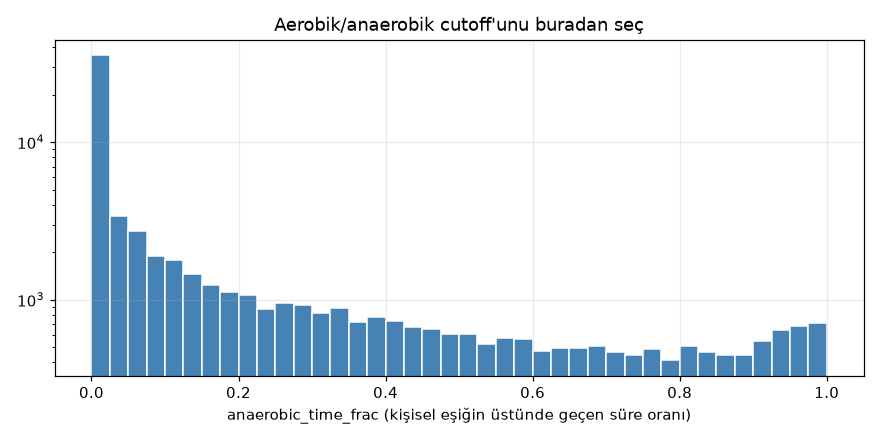

In [9]:
print(X["training_zone"].value_counts())
print(f"\nanaerobik oranı: %{100*(X['training_zone']=='anaerobik').mean():.1f}")

path = training_zone_histogram(X)
from IPython.display import Image, display
display(Image(path))

### Cutoff seçimini değerlendirirken nelere bakmalı

**İyi işaret:** sıfıra çok yakın büyük bir yığılma, sonra net bir boşluk.
Bu, aerobik ve anaerobik antrenmanların gerçekten iki ayrı grup
oluşturduğunu gösterir — `cutoff`'u bu boşluğun içine koymak makul bir
karar olur.

**Kötü/belirsiz işaret:** boşluk yok, dağılım sıfırdan itibaren
pürüzsüzce yükseliyor. Bu durumda hiçbir `cutoff` değeri "doğru" değildir
— ikili (aerobik/anaerobik) etiket yerine sürekli skoru
(`anaerobic_time_frac`) doğrudan kullanmak daha dürüst bir yaklaşım olur.

**Dikkat edilmesi gereken bir kalibrasyon sorunu:** dağılımın kuyruğunda
(0.85-1.0 arası, yani antrenmanın NEREDEYSE TAMAMININ eşiğin üstünde
geçtiği antrenmanlar) bir yığılma varsa bu şüphelidir. Fizyolojik olarak,
60+ dakikalık bir antrenmanın neredeyse tamamını eşiğin üstünde
sürdürmek çok zordur (vücut yorulur, tempo düşer). Böyle bir yığılma
görürsek, muhtemel iki açıklama var: (1) o kişinin çok az antrenmanı
var ve genel (kişisel olmayan) bir eşiğe düşmüş, ya da (2) o kişinin
"kişisel nabız tavanı" tek, bozuk bir antrenmandan hesaplanmış ve
gerçek değerinden çok daha düşük çıkmış — bu da diğer tüm antrenmanlarını
yapay olarak "eşiğin çok üstünde" gösteriyor. Aşağıdaki hücre bu iki
ihtimali test ediyor.

In [10]:
# Şüpheli yüksek anaerobic_time_frac değerlerinin kaynağını test et
counts = X.groupby("_user").size()
few = counts[counts < 5].index
print(f"5'ten az antrenmanı olan kullanıcı: {len(few)} / {counts.shape[0]}")
print(f"Bu kullanıcılara ait antrenman: {X['_user'].isin(few).sum()} / {len(X)}")

high = X["anaerobic_time_frac"] > 0.8
print(f"\nanaerobic_time_frac > 0.8 olan antrenman: {high.sum()}")
print(f"  bunların 'az antrenmanlı kullanıcı' oranı: "
      f"%{100*X.loc[high, '_user'].isin(few).mean():.1f}")
print(f"  genel veri setindeki oran (kıyas için): "
      f"%{100*X['_user'].isin(few).mean():.1f}")

# Eğer yukarıdaki iki oran birbirine yakınsa, sebep "az antrenman" DEĞİL —
# o zaman tek bir bozuk antrenmanın kişisel tavanı çarpıtması ihtimaline bak:
susp_users = X.loc[high, "_user"].unique()
print(f"\nŞüpheli antrenmanı olan {len(susp_users)} kullanıcı için "
      f"kendi içlerindeki hr_p95 aralığı (geniş aralık = tek antrenman çarpıtıyor olabilir):")
print(X[X['_user'].isin(susp_users)].groupby('_user')['hr_p95'].agg(['min','max','count']).head(10))

5'ten az antrenmanı olan kullanıcı: 110 / 797
Bu kullanıcılara ait antrenman: 234 / 69417

anaerobic_time_frac > 0.8 olan antrenman: 4400
  bunların 'az antrenmanlı kullanıcı' oranı: %0.3
  genel veri setindeki oran (kıyas için): %0.3

Şüpheli antrenmanı olan 465 kullanıcı için kendi içlerindeki hr_p95 aralığı (geniş aralık = tek antrenman çarpıtıyor olabilir):
         min         max  count
_user                          
69     142.0  180.000000     42
2358   125.0  193.000000    362
13653  157.0  205.014286    295
43462  187.0  187.000000      1
50404  156.0  175.000000      7
56331  136.0  208.050000    167
68009  115.0  211.000000    336
68129  141.0  188.000000    185
71988  149.0  183.050000     34
80118  107.0  184.050000    194


## 4. Gözle doğrulama 

Sayısal istatistikler (histogram, oranlar) yanıltıcı olabilir; etiketin
gerçekten anlamlı olduğundan emin olmanın en güvenilir yolu birkaç
antrenmanın ham hız ve nabız grafiğine bizzat bakmak. Beklediğimiz
görsel imza şu: **"anaerobik"** etiketli örneklerde nabız grafiğinde,
kişisel eşiğin üstüne çıkan net, belirgin bir bölüm görülmeli (efor
arttıkça nabız yükselir ve orada kalır). **"aerobik"** etiketli
örneklerde ise nabız daha sabit ve düşük seyretmeli, keskin sıçramalar
olmamalı. Eğer birkaç örnekte bu beklenen desenin tam tersini
görürseniz (örn. "anaerobik" etiketli ama nabzı düz bir çizgi), bu
pipeline'da bir hata olduğuna işaret eder — sayısal metrikler o hatayı
gizleyebilir ama grafik gizleyemez.

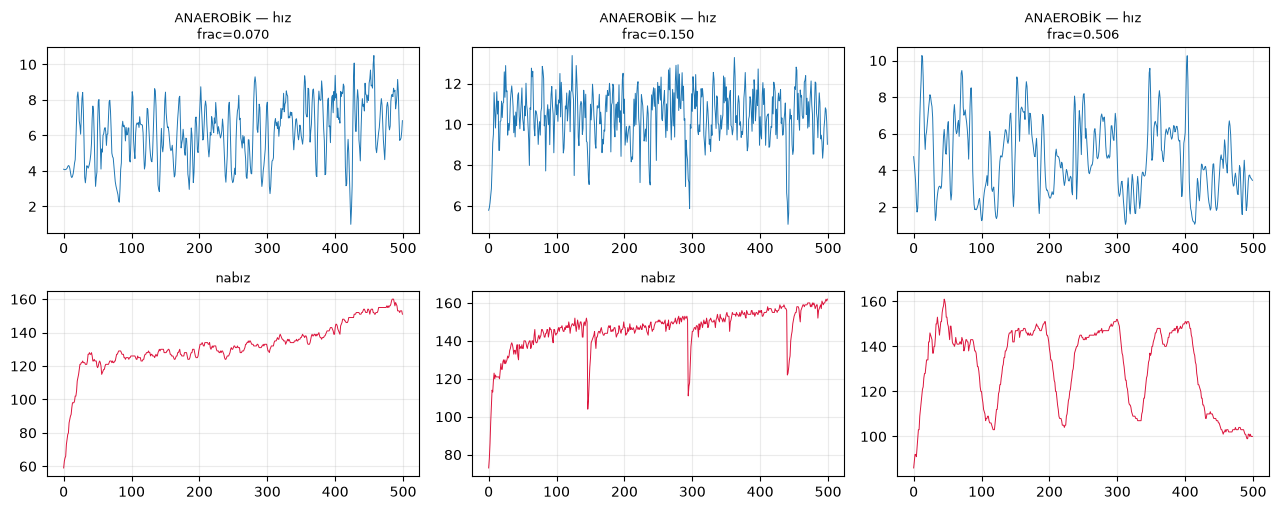

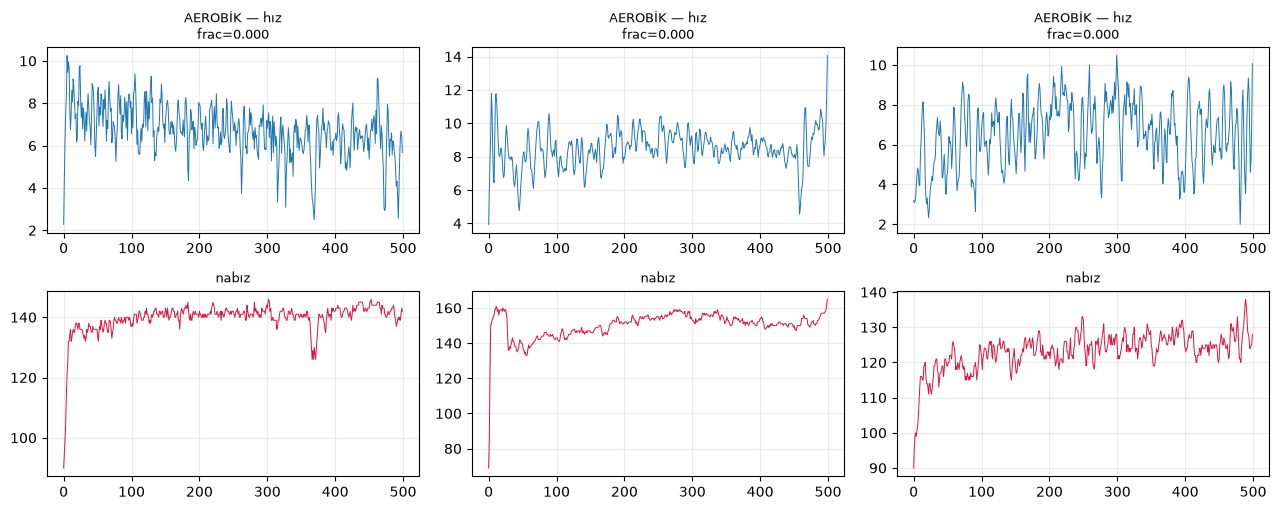

In [11]:
def show_samples(X, df, mask, title, n=3, seed=0):
    pool = X[mask]
    if len(pool) == 0:
        print(f"{title}: örnek yok"); return
    sel = pool.sample(min(n, len(pool)), random_state=seed)
    fig, axes = plt.subplots(2, len(sel), figsize=(4.3 * len(sel), 5.2), squeeze=False)
    for col, (idx, r) in enumerate(sel.iterrows()):
        axes[0, col].plot(df.loc[idx, "speed"], lw=0.7)
        axes[0, col].set_title(f"{title} — hız\nfrac={r.anaerobic_time_frac:.3f}", fontsize=9)
        axes[0, col].grid(alpha=0.25)
        axes[1, col].plot(df.loc[idx, "heart_rate"], lw=0.7, color="crimson")
        axes[1, col].set_title("nabız", fontsize=9)
        axes[1, col].grid(alpha=0.25)
    plt.tight_layout(); plt.show()

show_samples(X, df, X["training_zone"] == "anaerobik", "ANAEROBİK", n=3)
show_samples(X, df, X["training_zone"] == "aerobik", "AEROBİK", n=3)

## 5. Sonucu kaydet

Her antrenman için nihai etiketi (`training_zone`) ve sürekli skoru
(`anaerobic_time_frac`) — ayrıca yorumlanabilirlik için süre, mesafe,
hız ve nabız özetlerini — `aerobik_anaerobik.csv` dosyasına yazıyoruz.
Bu dosya, projenin bir sonraki adımında (LSTM'in eğitim verisine bu
etiketin özellik olarak eklenmesi) girdi olarak kullanılacak.

In [12]:
out_cols = ["training_zone", "anaerobic_time_frac", "duration_min",
           "distance_km", "speed_med", "hr_med", "hr_reserve_frac"]
out = X[out_cols]
out.to_csv("aerobik_anaerobik.csv", index=True)
print(f"{len(out)} antrenman kaydedildi -> aerobik_anaerobik.csv")
out["training_zone"].value_counts()

69417 antrenman kaydedildi -> aerobik_anaerobik.csv


training_zone
aerobik      34899
anaerobik    34518
Name: count, dtype: int64